#1. Loading the Taxis Dataset:

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

#Load the 'taxis' dataset
df = sns.load_dataset("taxis")


In [3]:
df

,pickup,dropoff,passengers,distance,fare,tip,tolls,total,color,payment,pickup_zone,dropoff_zone,pickup_borough,dropoff_borough
0,2019-03-23 20:21:09,2019-03-23 20:27:24,1,1.60,7.0,2.15,0.0,12.95,yellow,credit card,Lenox Hill West,UN/Turtle Bay South,Manhattan,Manhattan
1,2019-03-04 16:11:55,2019-03-04 16:19:00,1,0.79,5.0,0.00,0.0,9.30,yellow,cash,Upper West Side South,Upper West Side South,Manhattan,Manhattan
2,2019-03-27 17:53:01,2019-03-27 18:00:25,1,1.37,7.5,2.36,0.0,14.16,yellow,credit card,Alphabet City,West Village,Manhattan,Manhattan
3,2019-03-10 01:23:59,2019-03-10 01:49:51,1,7.70,27.0,6.15,0.0,36.95,yellow,credit card,Hudson Sq,Yorkville West,Manhattan,Manhattan
4,2019-03-30 13:27:42,2019-03-30 13:37:14,3,2.16,9.0,1.10,0.0,13.40,yellow,credit card,Midtown East,Yorkville West,Manhattan,Manhattan
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6428,2019-03-31 09:51:53,2019-03-31 09:55:27,1,0.75,4.5,1.06,0.0,6.36,green,credit card,East Harlem North,Central Harlem North,Manhattan,Manhattan
6429,2019-03-31 17:38:00,2019-03-31 18:34:23,1,18.74,58.0,0.00,0.0,58.80,green,credit card,Jamaica,East Concourse/Concourse Village,Queens,Bronx
6430,2019-03-23 22:55:18,2019-03-23 23:14:25,1,4.14,16.0,0.00,0.0,17.30,green,cash,Crown Heights North,Bushwick North,Brooklyn,Brooklyn
6431,2019-03-04 10:09:25,2019-03-04 10:14:29,1,1.12,6.0,0.00,0.0,6.80,green,credit card,East New York,East Flatbush/Remsen Village,Brooklyn,Brooklyn


In [4]:
df.shape

(6433, 14)

In [5]:
df.columns

Index(['pickup', 'dropoff', 'passengers', 'distance', 'fare', 'tip', 'tolls',
       'total', 'color', 'payment', 'pickup_zone', 'dropoff_zone',
       'pickup_borough', 'dropoff_borough'],
      dtype='object')

#2. Handing Missing Values:

In [6]:
#2. Check for missing values:
print(df.isnull().sum())

pickup              0
dropoff             0
passengers          0
distance            0
fare                0
tip                 0
tolls               0
total               0
color               0
payment            44
pickup_zone        26
dropoff_zone       45
pickup_borough     26
dropoff_borough    45
dtype: int64


In [7]:
#Impute missing values:

#numerical columns:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
#categorical columns:
cat_cols = df.select_dtypes(include=['object', 'category']).columns

for col in num_cols:
    df[col] = df[col].fillna(df[col].mean())
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [8]:
print(df.isnull().sum())

pickup             0
dropoff            0
passengers         0
distance           0
fare               0
tip                0
tolls              0
total              0
color              0
payment            0
pickup_zone        0
dropoff_zone       0
pickup_borough     0
dropoff_borough    0
dtype: int64


In [9]:
#remove rows with missing values:
df.dropna(subset=['pickup', 'dropoff'])

,pickup,dropoff,passengers,distance,fare,tip,tolls,total,color,payment,pickup_zone,dropoff_zone,pickup_borough,dropoff_borough
0,2019-03-23 20:21:09,2019-03-23 20:27:24,1,1.60,7.0,2.15,0.0,12.95,yellow,credit card,Lenox Hill West,UN/Turtle Bay South,Manhattan,Manhattan
1,2019-03-04 16:11:55,2019-03-04 16:19:00,1,0.79,5.0,0.00,0.0,9.30,yellow,cash,Upper West Side South,Upper West Side South,Manhattan,Manhattan
2,2019-03-27 17:53:01,2019-03-27 18:00:25,1,1.37,7.5,2.36,0.0,14.16,yellow,credit card,Alphabet City,West Village,Manhattan,Manhattan
3,2019-03-10 01:23:59,2019-03-10 01:49:51,1,7.70,27.0,6.15,0.0,36.95,yellow,credit card,Hudson Sq,Yorkville West,Manhattan,Manhattan
4,2019-03-30 13:27:42,2019-03-30 13:37:14,3,2.16,9.0,1.10,0.0,13.40,yellow,credit card,Midtown East,Yorkville West,Manhattan,Manhattan
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6428,2019-03-31 09:51:53,2019-03-31 09:55:27,1,0.75,4.5,1.06,0.0,6.36,green,credit card,East Harlem North,Central Harlem North,Manhattan,Manhattan
6429,2019-03-31 17:38:00,2019-03-31 18:34:23,1,18.74,58.0,0.00,0.0,58.80,green,credit card,Jamaica,East Concourse/Concourse Village,Queens,Bronx
6430,2019-03-23 22:55:18,2019-03-23 23:14:25,1,4.14,16.0,0.00,0.0,17.30,green,cash,Crown Heights North,Bushwick North,Brooklyn,Brooklyn
6431,2019-03-04 10:09:25,2019-03-04 10:14:29,1,1.12,6.0,0.00,0.0,6.80,green,credit card,East New York,East Flatbush/Remsen Village,Brooklyn,Brooklyn


#3. Visualizations using Matplotlib/Pandas Plot:

Line Chart:

In [10]:
#Ensure the pickup column is converted to a datetime:
df.dtypes

,0
pickup,datetime64[ns]
dropoff,datetime64[ns]
passengers,int64
distance,float64
fare,float64
tip,float64
tolls,float64
total,float64
color,object
payment,object


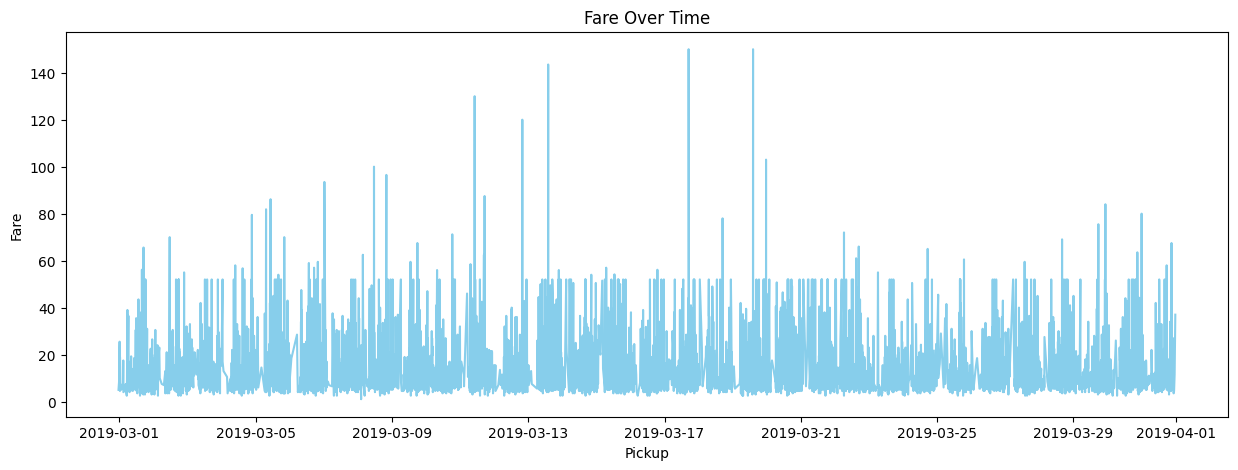

In [12]:
#Plot a line chart to visualize the fare over time:
import matplotlib.pyplot as plt

#sort values by pickkup time:
df=df.sort_values('pickup')

plt.figure(figsize=(15,5))
plt.plot(df['pickup'],df['fare'],color="skyblue")
plt.xlabel("Pickup")
plt.ylabel("Fare")
plt.title("Fare Over Time")
plt.show()

Bar Chart:

/tmp/ipython-input-423/1254760679.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=fare_by_borough, x="pickup_borough", y="fare", palette="viridis")


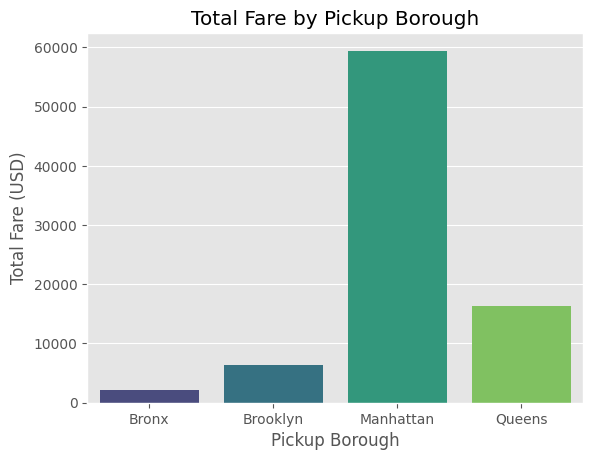

In [ ]:
# Group by pickup_borough and sum fares
fare_by_borough = df.groupby("pickup_borough")["fare"].sum().reset_index()

# Plot bar chart
plt.figure()
sns.barplot(data=fare_by_borough, x="pickup_borough", y="fare", palette="viridis")

plt.title("Total Fare by Pickup Borough")
plt.xlabel("Pickup Borough")
plt.ylabel("Total Fare (USD)")
plt.show()

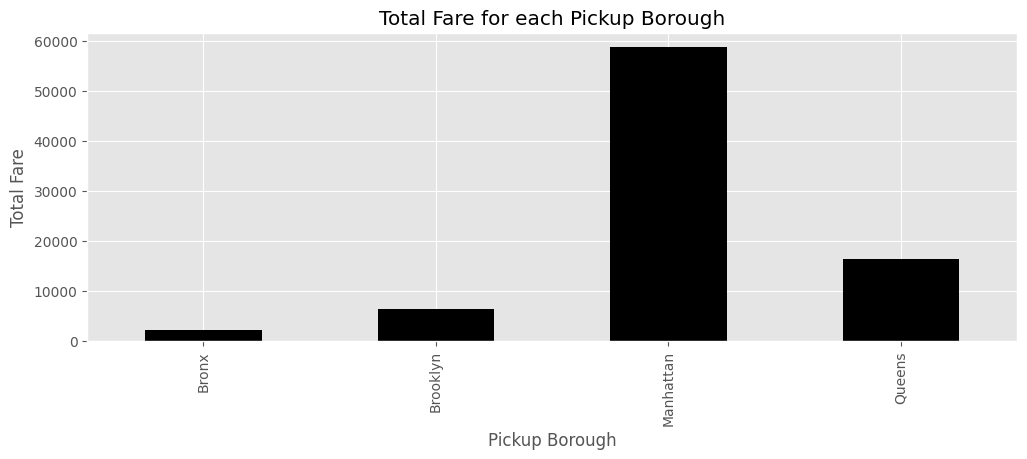

In [ ]:
borough_fare = df.groupby('pickup_borough')['fare'].sum()

plt.figure(figsize=(12,4))
borough_fare.plot(kind='bar',color="black")

plt.xlabel("Pickup Borough")
plt.ylabel("Total Fare")
plt.title("Total Fare for each Pickup Borough")
plt.show()

Pie Chart:

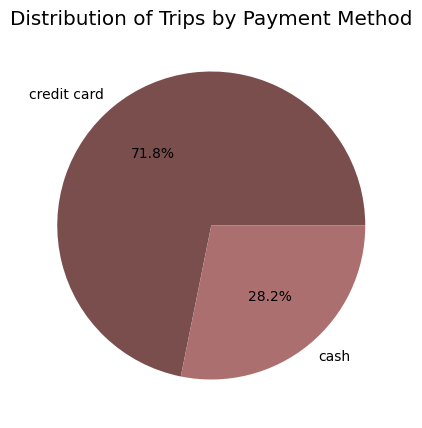

In [ ]:
payment_counts = df['payment'].value_counts()

plt.figure(figsize=(5,5))
plt.pie(payment_counts, labels=payment_counts.index, autopct='%1.1f%%',colors=sns.color_palette('pink'))
plt.title("Distribution of Trips by Payment Method")
plt.show()

Histogram:

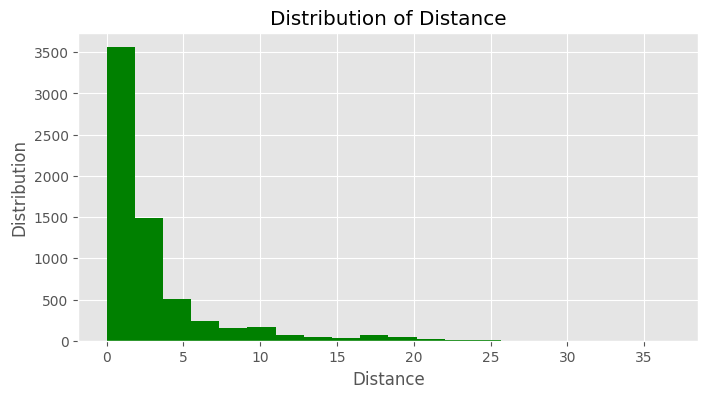

In [ ]:
plt.figure(figsize=(8,4))
plt.hist(df['distance'], bins=20, color="green")

plt.xlabel("Distance")
plt.ylabel("Distribution")
plt.title("Distribution of Distance")
plt.show()

Box Plot:

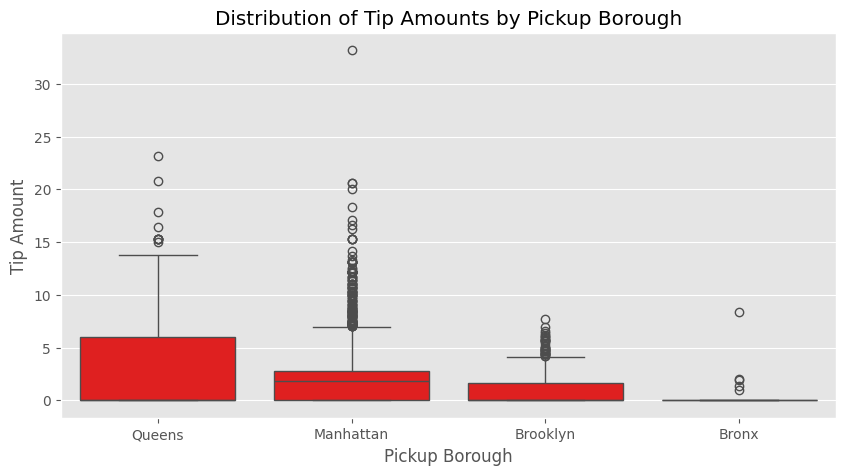

In [ ]:
plt.figure(figsize=(10,5))
sns.boxplot(data=df, x="pickup_borough", y="tip",color="red")

plt.title("Distribution of Tip Amounts by Pickup Borough")
plt.xlabel("Pickup Borough")
plt.ylabel("Tip Amount")
plt.show()

#Visualizations using Seaborn

Count Plot:

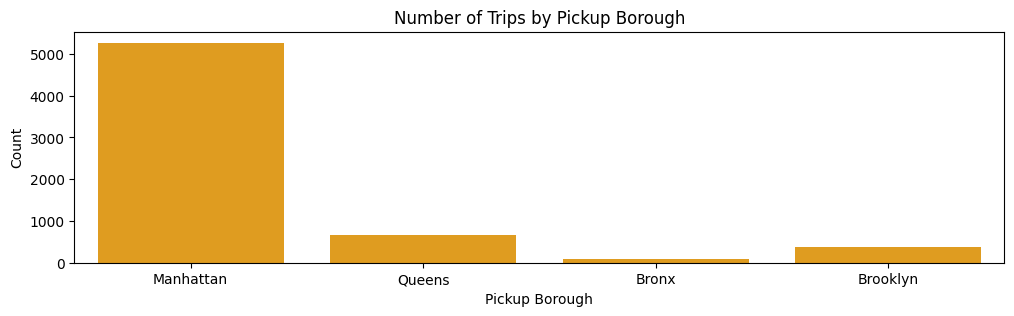

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset
df = sns.load_dataset("taxis")

plt.figure(figsize=(12,3))
sns.countplot(data=df, x="pickup_borough", color="orange")

plt.title("Number of Trips by Pickup Borough")
plt.xlabel("Pickup Borough")
plt.ylabel("Count")
plt.show()

Scatter Plot:

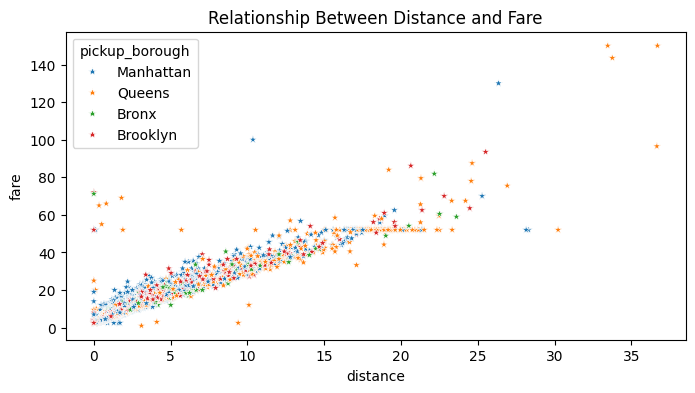

In [ ]:
plt.figure(figsize=(8,4))
sns.scatterplot(data=df,x='distance', y='fare', hue='pickup_borough',marker="*")
plt.title("Relationship Between Distance and Fare")
plt.show()

Heatmap:

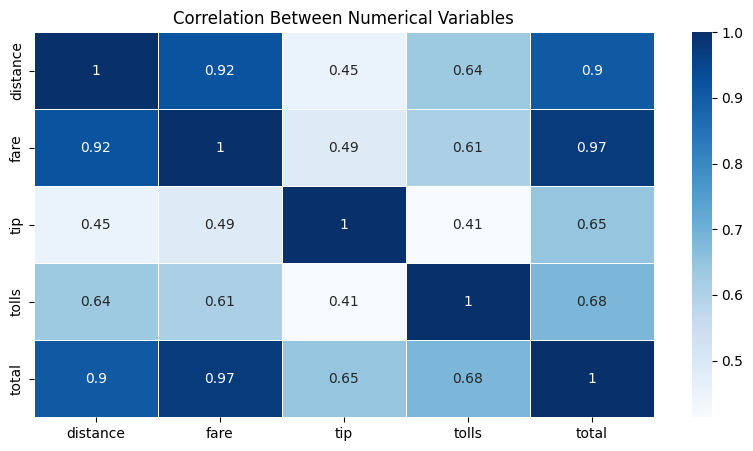

In [ ]:
# Select numerical columns
corr = df[['distance', 'fare', 'tip', 'tolls', 'total']].corr()

plt.figure(figsize=(10,5))
sns.heatmap(corr, annot=True, cmap="Blues", linewidths=0.5)
plt.title("Correlation Between Numerical Variables")
plt.show()

Pair Plot:

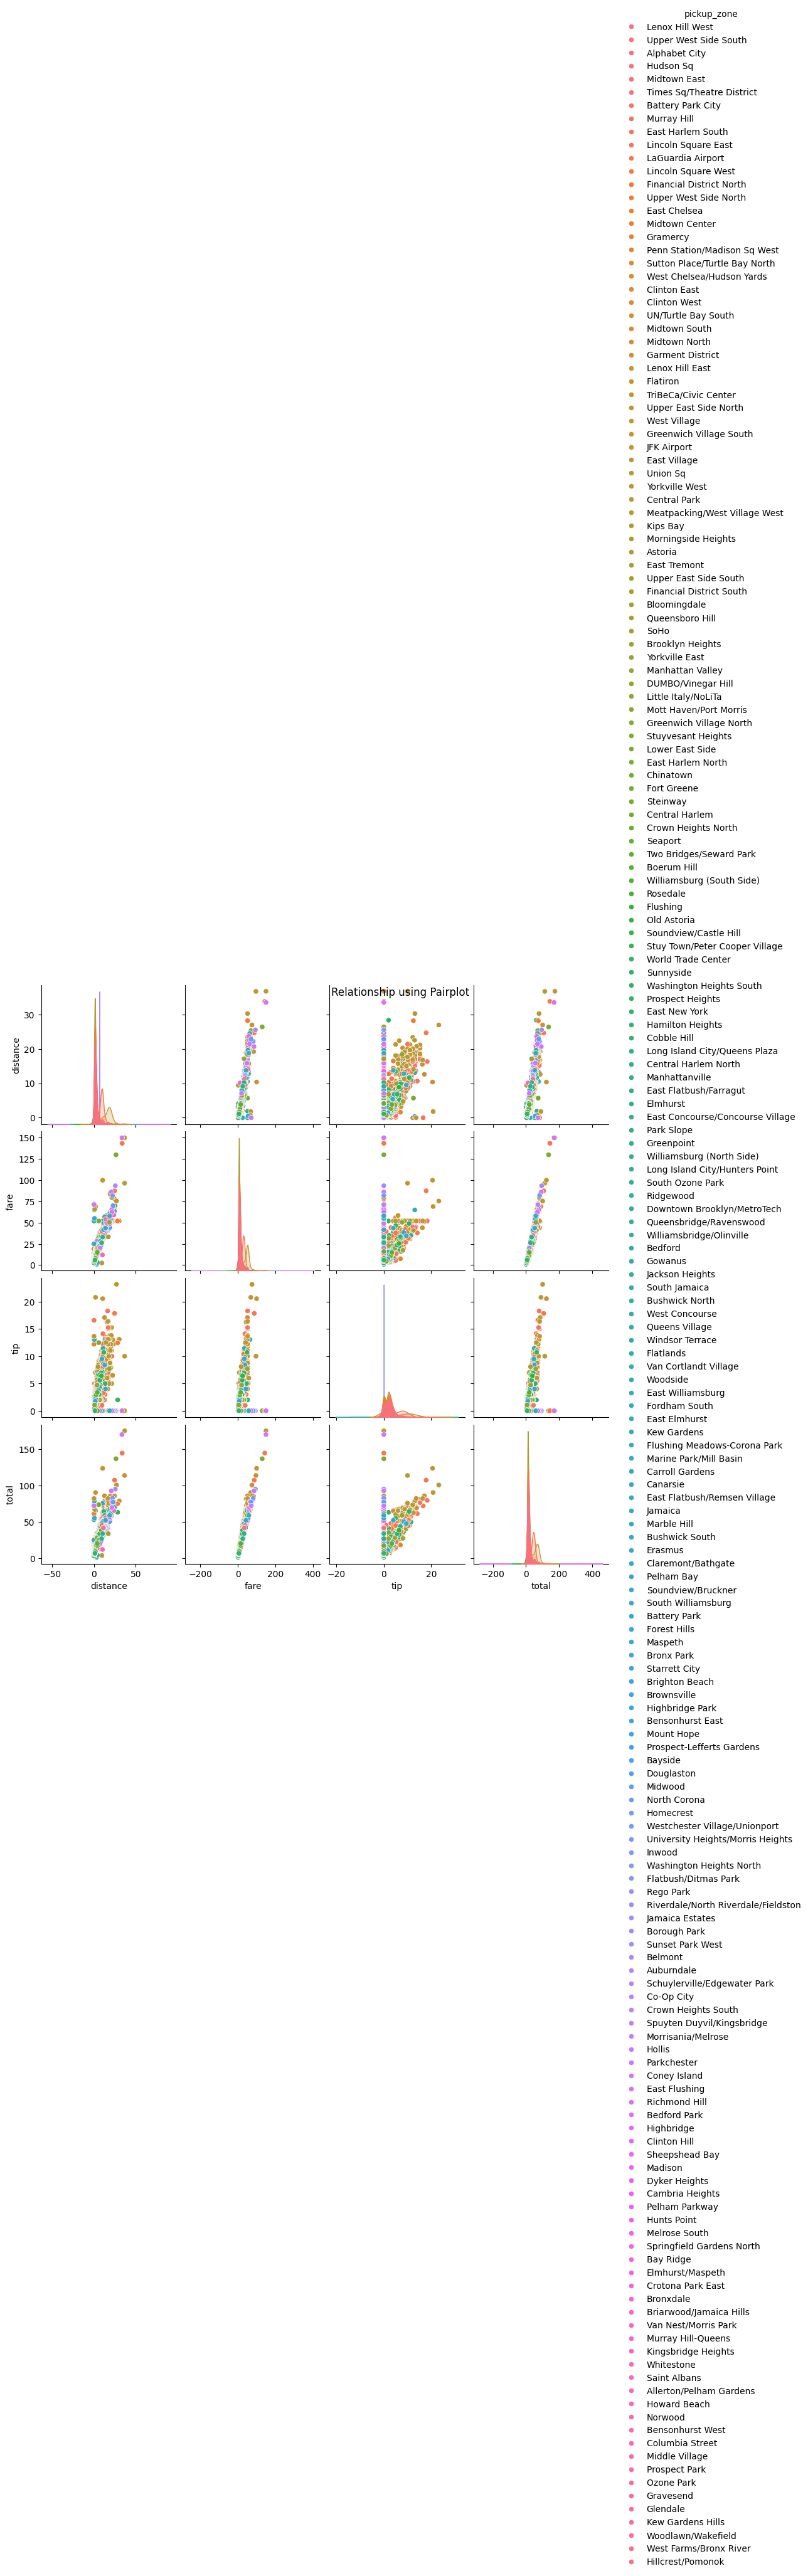

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset
df = sns.load_dataset("taxis")

sns.pairplot(df[['distance', 'fare', 'tip', 'total', 'pickup_zone']],
             hue='pickup_zone')
plt.suptitle("Relationship using Pairplot")
plt.show()

Violin Plot:

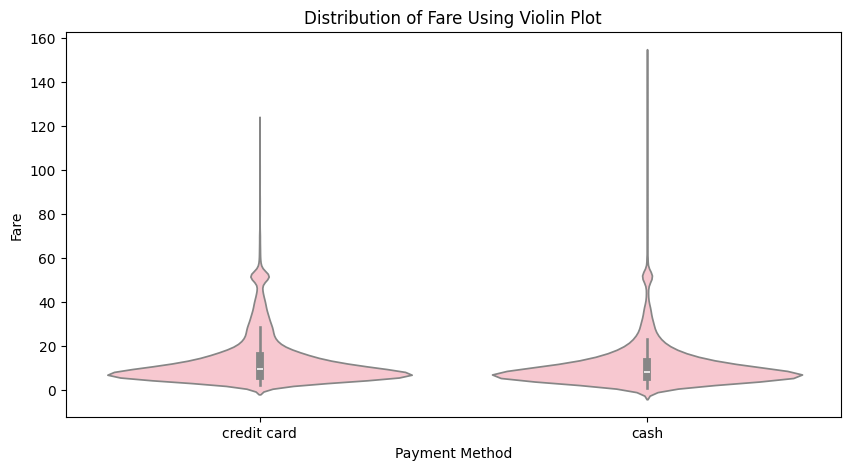

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

df=sns.load_dataset("taxis")

plt.figure(figsize=(10,5))
sns.violinplot(data=df, x='payment', y='fare', color='pink')
plt.title("Distribution of Fare Using Violin Plot")
plt.xlabel('Payment Method')
plt.ylabel('Fare')
plt.show()